In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split


In [2]:
#%pip install squarify

In [3]:
df = pd.read_csv('C:/data/GitHub/BZIA_VM/ETL/BI_Project/Open_Data_Analytics_7939237139655295132.csv')

df.head()

,Dataset,OD_ID,Date,Usage,SOURCE,LAST_UPDATED,ObjectId
0,BID Area Rates,OD21,1/6/2015 12:00:00 AM,3,ARCGIS,6/18/2018 12:00:00 AM,1
1,Zoning Boundaries,OD22,1/6/2015 12:00:00 AM,35,ARCGIS,6/18/2018 12:00:00 AM,2
2,Solid Waste Collection Areas,OD23,1/6/2015 12:00:00 AM,11,ARCGIS,6/18/2018 12:00:00 AM,3
3,Transit Area Rates,OD24,1/6/2015 12:00:00 AM,46,ARCGIS,6/18/2018 12:00:00 AM,4
4,Street Centrelines,OD27,1/6/2015 12:00:00 AM,315,ARCGIS,6/18/2018 12:00:00 AM,5


In [4]:
df.info

<bound method DataFrame.info of                                          Dataset OD_ID  \
0                                 BID Area Rates  OD21   
1                              Zoning Boundaries  OD22   
2                   Solid Waste Collection Areas  OD23   
3                             Transit Area Rates  OD24   
4                             Street Centrelines  OD27   
...                                          ...   ...   
639103                        Horticultural Beds  OD85   
639104  Bike Infrastructure and Suggested Routes  OD92   
639105                           Grass Inventory  OD94   
639106                                Ice Routes  OD98   
639107             PPL&C Permit Processing Times  OD99   

                          Date  Usage  SOURCE            LAST_UPDATED  \
0         1/6/2015 12:00:00 AM      3  ARCGIS   6/18/2018 12:00:00 AM   
1         1/6/2015 12:00:00 AM     35  ARCGIS   6/18/2018 12:00:00 AM   
2         1/6/2015 12:00:00 AM     11  ARCGIS   6/18

In [5]:
df.isna().sum()

Dataset         0
OD_ID           0
Date            0
Usage           0
SOURCE          0
LAST_UPDATED    0
ObjectId        0
dtype: int64

In [6]:
df.shape

(639108, 7)

In [7]:
df.nunique()

Dataset            237
OD_ID              237
Date              4131
Usage            13033
SOURCE               1
LAST_UPDATED       386
ObjectId        639108
dtype: int64

In [8]:
df.groupby('Dataset', as_index=False).agg(
    Usage_sum=('Usage', 'sum'),
    Usage_mean=('Usage', 'mean')
)

,Dataset,Usage_sum,Usage_mean
0,2031 Commuting Mode Share Targets,130972,56.187044
1,311 Call Details,1951222,1169.096465
2,311 Call Volumes,496566,143.932174
3,Accessible Parking Spots,3259024,1058.468334
4,Active Travelways,6243133,1809.603768
...,...,...,...
232,Volunteer Recruitment Areas,725624,358.687098
233,Youth Advocate Program,621120,184.912176
234,Zoning Boundaries,91508850,18364.208308
235,Zoning Boundaries 2019,103015,49.242352


In [9]:
agg_df = df.groupby('Dataset').agg(
    Usage_sum=('Usage', 'sum'),
    ObjectId_nunique=('ObjectId', 'nunique'),
    Date_min=('Date', 'min'),
    Date_max=('Date', 'max')
).reset_index()

In [10]:
print(df.columns.tolist())

['Dataset', 'OD_ID', 'Date', 'Usage', 'SOURCE', 'LAST_UPDATED', 'ObjectId']


In [11]:
# Inspect columns
print(df.columns.tolist())

# Clean column names (optional but helpful)
df.columns = df.columns.str.strip()

# Group and summarize
summary = (
    df.groupby('Dataset', as_index=False)
      .agg(
          rows=('ObjectId', 'count'),   # or .size() pattern if you prefer row counts
          distinct_ObjectId=('ObjectId', 'nunique'),
          total_Usage=('Usage', 'sum')
      )
)
summary.head()

['Dataset', 'OD_ID', 'Date', 'Usage', 'SOURCE', 'LAST_UPDATED', 'ObjectId']


,Dataset,rows,distinct_ObjectId,total_Usage
0,2031 Commuting Mode Share Targets,2331,2331,130972
1,311 Call Details,1669,1669,1951222
2,311 Call Volumes,3450,3450,496566
3,Accessible Parking Spots,3079,3079,3259024
4,Active Travelways,3450,3450,6243133


In [12]:
topN = df.groupby('Dataset')['Usage'].sum().nlargest(30).index
df_top = df[df['Dataset'].isin(topN)]

C:\Users\biauser\AppData\Local\Temp\ipykernel_9764\1159104536.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


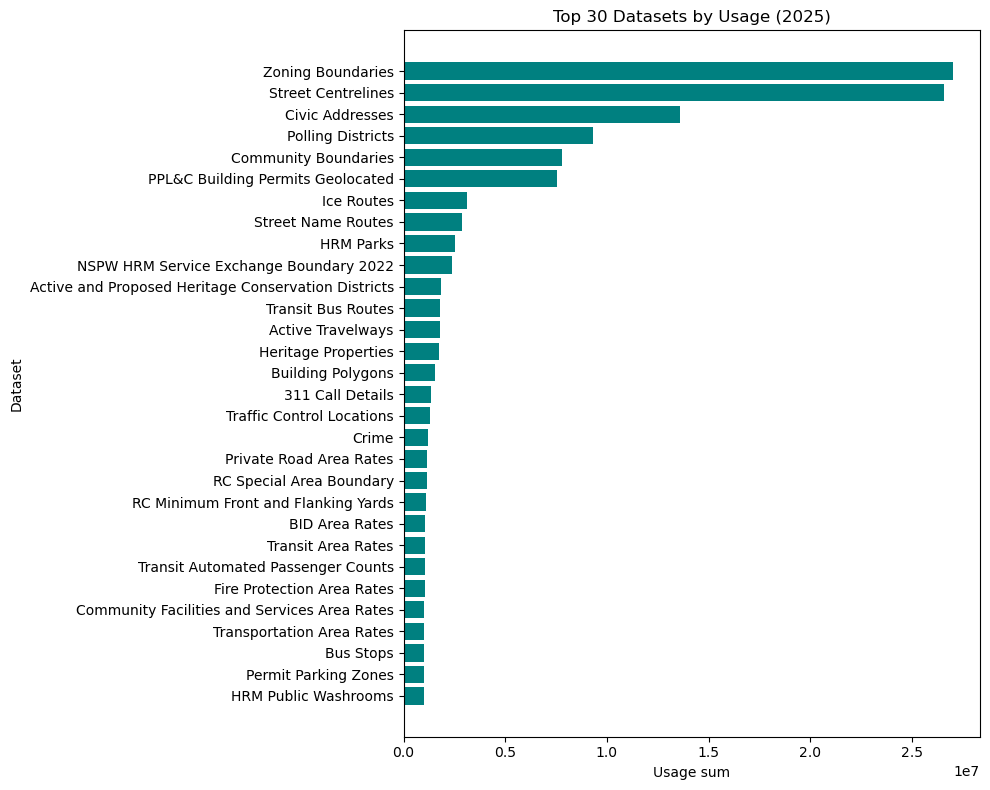

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df_2025 = df[df['Date'].dt.year == 2025].copy()

usage_2025 = df_2025.groupby('Dataset', as_index=False)['Usage'].sum()
usage_2025 = usage_2025.sort_values('Usage', ascending=True).tail(30)

plt.figure(figsize=(10, 8))
plt.barh(usage_2025['Dataset'], usage_2025['Usage'], color='teal')
plt.title('Top 30 Datasets by Usage (2025)')
plt.xlabel('Usage sum')
plt.ylabel('Dataset')
plt.tight_layout()
plt.show()

In [14]:
#['Dataset', 'OD_ID', 'Date', 'Usage', 'SOURCE', 'LAST_UPDATED', 'ObjectId']

In [17]:
df = pd.read_csv('C:/data/GitHub/BZIA_VM/ETL/BI_Project/Open_Data_Analytics_7939237139655295132.csv')
X = df[['Dataset', 'OD_ID', 'Date', 'SOURCE', 'LAST_UPDATED', 'ObjectId']]
y = df['Usage']
X,y

(                                         Dataset OD_ID  \
 0                                 BID Area Rates  OD21   
 1                              Zoning Boundaries  OD22   
 2                   Solid Waste Collection Areas  OD23   
 3                             Transit Area Rates  OD24   
 4                             Street Centrelines  OD27   
 ...                                          ...   ...   
 639103                        Horticultural Beds  OD85   
 639104  Bike Infrastructure and Suggested Routes  OD92   
 639105                           Grass Inventory  OD94   
 639106                                Ice Routes  OD98   
 639107             PPL&C Permit Processing Times  OD99   
 
                           Date  SOURCE            LAST_UPDATED  ObjectId  
 0         1/6/2015 12:00:00 AM  ARCGIS   6/18/2018 12:00:00 AM         1  
 1         1/6/2015 12:00:00 AM  ARCGIS   6/18/2018 12:00:00 AM         2  
 2         1/6/2015 12:00:00 AM  ARCGIS   6/18/2018 12:00:00 A

In [18]:
# Dates to datetime
X['Date'] = pd.to_datetime(X['Date'], errors='coerce')
X['LAST_UPDATED'] = pd.to_datetime(X['LAST_UPDATED'], errors='coerce')

# Optionally extract features from dates
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month

# Encode categoricals (Dataset, SOURCE) for scikit-learn
X_model = pd.get_dummies(X[['Dataset','SOURCE','OD_ID','ObjectId','Year','Month']], drop_first=True)

# Make sure y is numeric
y = pd.to_numeric(y, errors='coerce').fillna(0)

C:\Users\biauser\AppData\Local\Temp\ipykernel_9764\607888988.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['Date'] = pd.to_datetime(X['Date'], errors='coerce')
C:\Users\biauser\AppData\Local\Temp\ipykernel_9764\607888988.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Date'] = pd.to_datetime(X['Date'], errors='coerce')
C:\Users\biauser\AppData\Local\Temp\ipykernel_9764\607888988.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  X['LAST_UPDATED'] = pd.to_d

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

print("Training test size:", X_train.shape)
print("Test set size:", X_test.shape)

Training test size: (428202, 8)
Test set size: (210906, 8)


In [23]:
model = LinearRegression()
model.fit(X,y)

ValueError: could not convert string to float: 'BID Area Rates'